In [137]:
#Import packages
#---------------------------------------
import sys
import os
import glob
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import kedm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#Import your modules
#---------------------------------------
import admin_functions as adfn
import CCM as cfn
# Define paths
#----------------------------------------------------------------------
code = '~/Documents/empirical_dynamic_modelling'
data = '/snl/scratch25/dburrows/CCM'

%load_ext autoreload
sys.version

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'3.7.4 (default, Aug 13 2019, 20:35:49) \n[GCC 7.3.0]'

# Define seizure segments from PTZ20 data

In [143]:
sz_li = np.sort(glob.glob(data + '/*PTZ20*1_regtrace*'))
dff_li = np.sort(glob.glob(data + '/*PTZ20*1_regdeltaff*'))
len(sz_li)

9

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


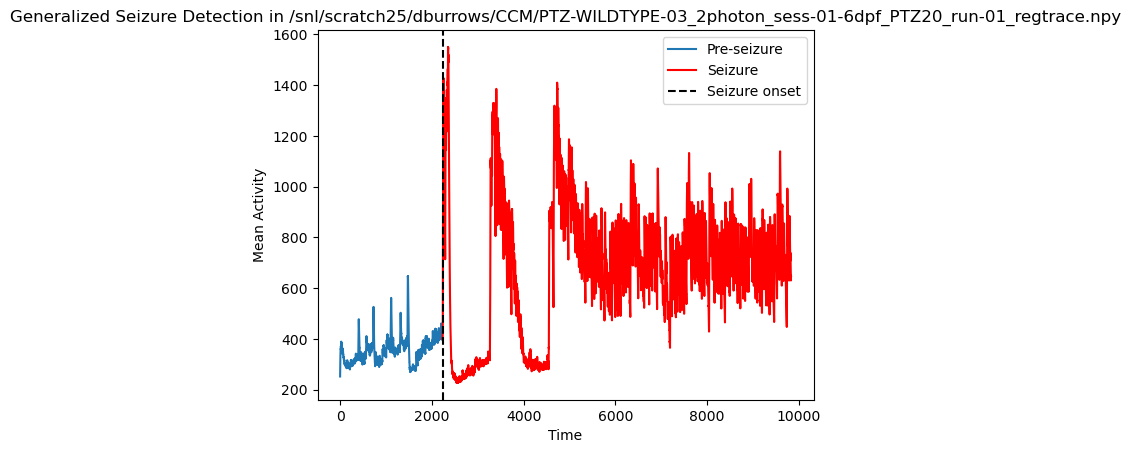

Seizure onset at index: 2233
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


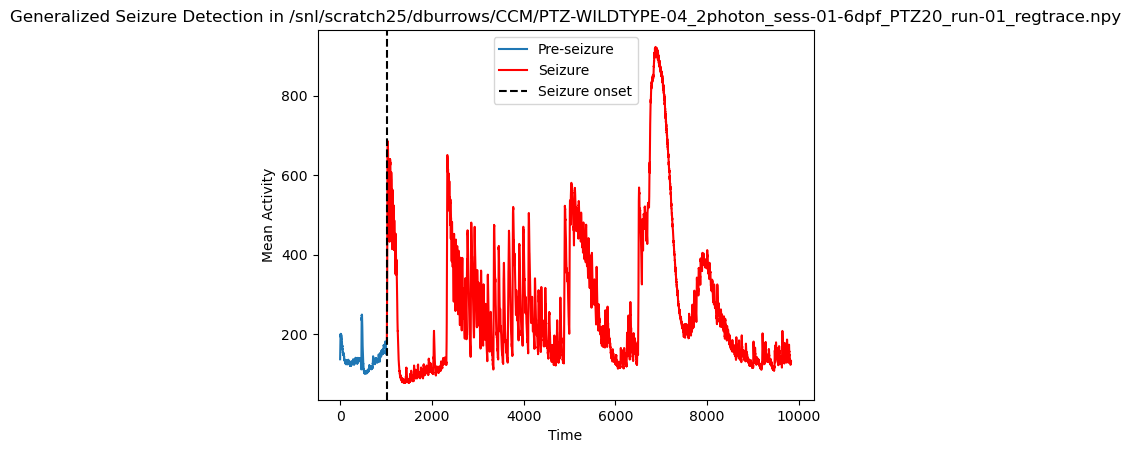

Seizure onset at index: 1019
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


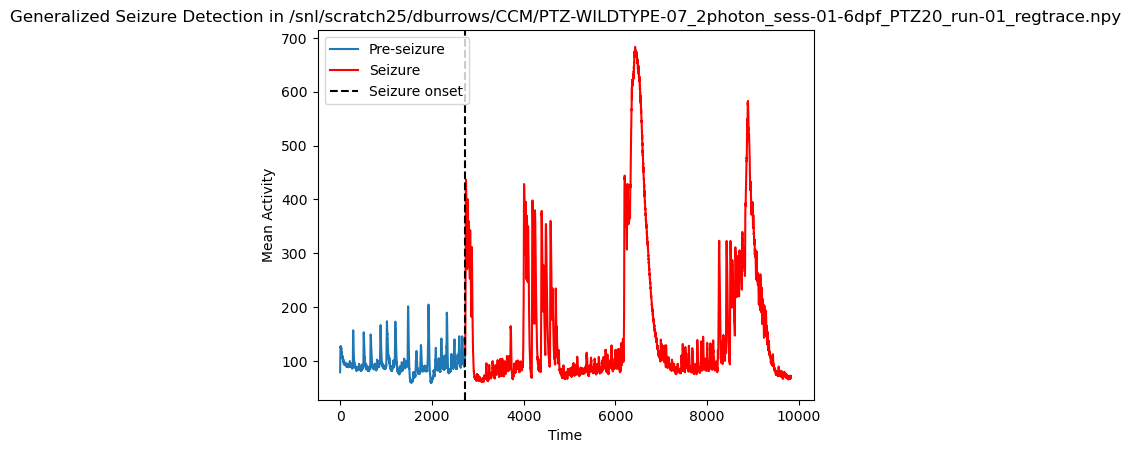

Seizure onset at index: 2726
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


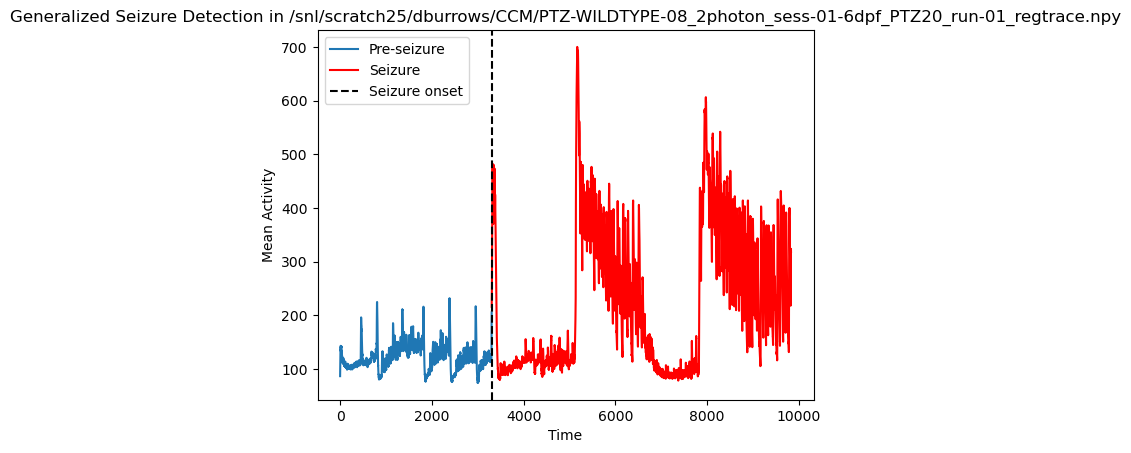

Seizure onset at index: 3304
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-09_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


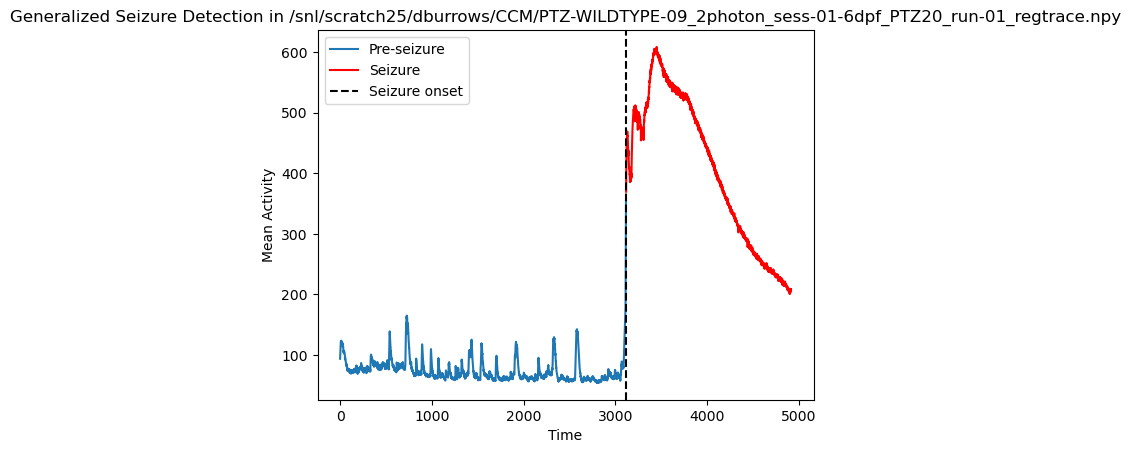

Seizure onset at index: 3116
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


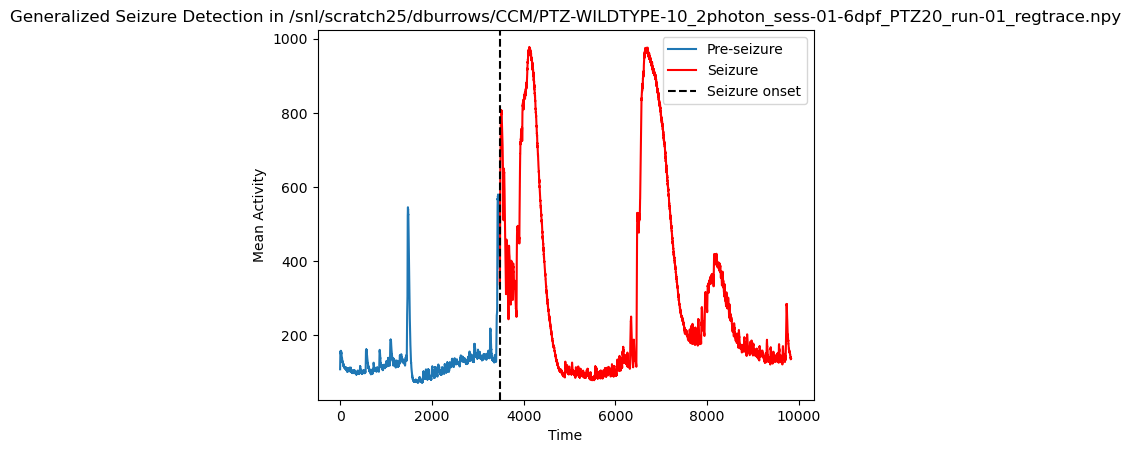

Seizure onset at index: 3480
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


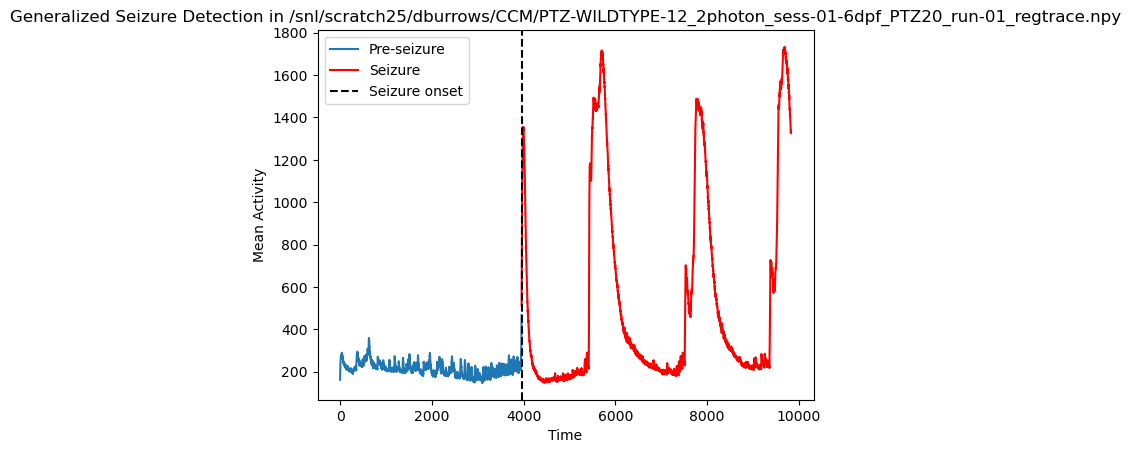

Seizure onset at index: 3956
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


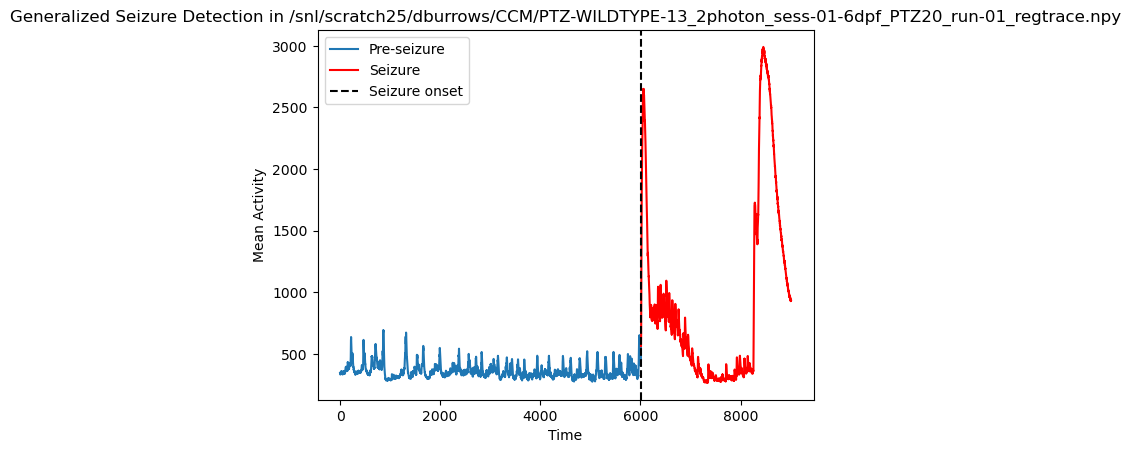

Seizure onset at index: 6011
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


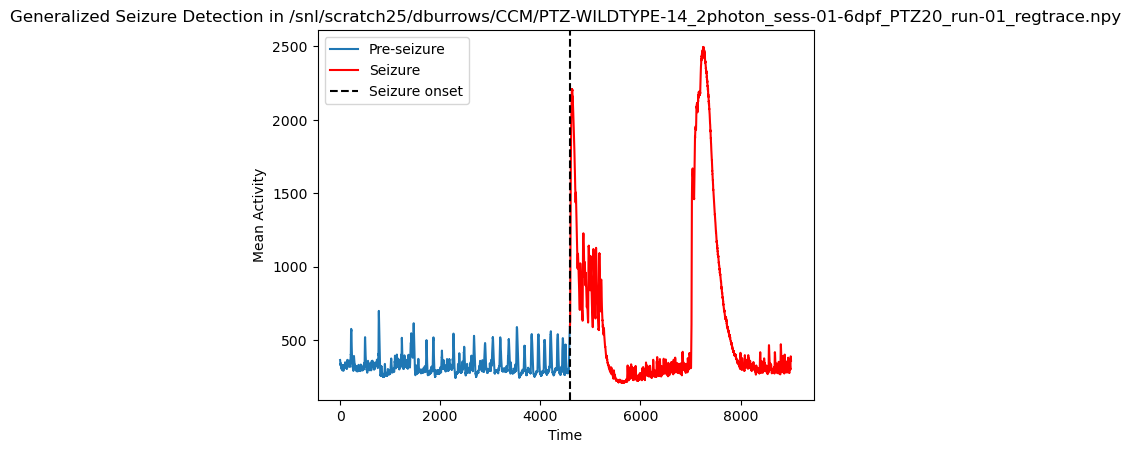

Seizure onset at index: 4592


In [105]:
import numpy as np
import matplotlib.pyplot as plt

for i in sz_li:
    curr = np.load(i)  # shape: (n_neurons, n_timepoints)
    print(i)

    mean_activity = np.mean(curr, axis=0)
    baseline_mean = np.mean(mean_activity)
    baseline_std = np.std(mean_activity)

    # Find first index where mean activity > mean + 3 * std
    threshold = baseline_mean + 1.5 * baseline_std
    seizure_start_idx = np.argmax(mean_activity > threshold)-10


    # Time indices of generalized seizure
    seizure_indices = np.arange(seizure_start_idx, len(mean_activity))

    # Plot
    plt.figure()
    plt.plot(mean_activity[:seizure_start_idx], label='Pre-seizure')
    plt.plot(seizure_indices, mean_activity[seizure_start_idx:], color='red', label='Seizure')
    plt.axvline(seizure_start_idx, color='black', linestyle='--', label='Seizure onset')
    plt.title(f"Generalized Seizure Detection in {i}")
    plt.xlabel("Time")
    plt.ylabel("Mean Activity")
    plt.legend()
    plt.show()

    # Optional: return/save seizure start indices
    print(f"Seizure onset at index: {seizure_start_idx}")

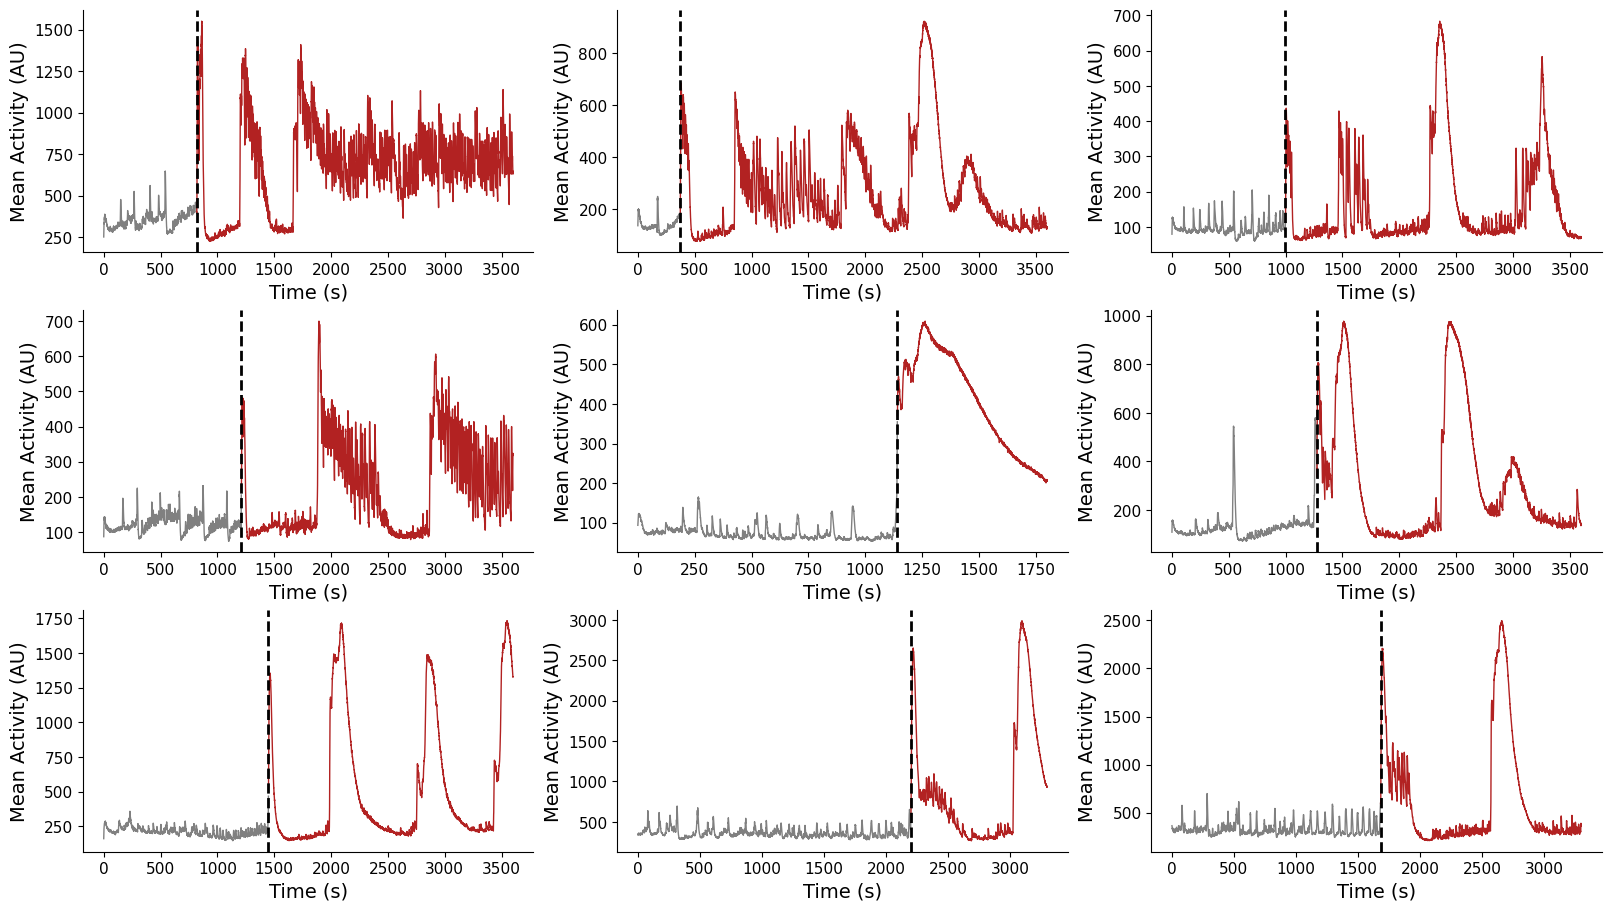

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set up the figure with more columns (wider layout)
n_plots = len(sz_li)
n_cols = 3  # Increased from 2 to 3 for wider layout
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3), constrained_layout=True)
axes = axes.flatten()

for idx, i in enumerate(sz_li):
    curr = np.load(i)  # shape: (n_neurons, n_timepoints)
    mean_activity = np.mean(curr, axis=0)
    baseline_mean = np.mean(mean_activity)
    baseline_std = np.std(mean_activity)

    threshold = baseline_mean + 1.5 * baseline_std
    seizure_start_idx = np.argmax(mean_activity > threshold) - 10
    seizure_start_idx = max(seizure_start_idx, 0)

    seizure_indices = np.arange(seizure_start_idx, len(mean_activity))
    
    ax = axes[idx]
    ax.plot(np.arange(0, seizure_start_idx)/2.73, mean_activity[:seizure_start_idx], label='Pre-seizure', linewidth=1.0, color='grey')
    ax.plot(seizure_indices/2.73, mean_activity[seizure_start_idx:], color='firebrick', label='Seizure', linewidth=1)
    ax.axvline(seizure_start_idx/2.73, color='black', linestyle='--', linewidth=2.0)
    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("Mean Activity (AU)", fontsize=14)
    ax.tick_params(labelsize=11)
    ax.set_title("")  # No title for cleaner layout
    # Save the wider figure
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])



plt.savefig("seizure_detection.svg", format='svg')
plt.show()


In [101]:
#extract
import numpy as np
import matplotlib.pyplot as plt

for x,i in enumerate(sz_li):
    curr = np.load(i)  # shape: (n_neurons, n_timepoints)
    curr_dff = np.load(dff_li[x])
    name = os.path.basename(i)[:os.path.basename(i).find('run-01')+6]
    print(i)

    mean_activity = np.mean(curr, axis=0)
    baseline_mean = np.mean(mean_activity)
    baseline_std = np.std(mean_activity)

    # Find first index where mean activity > mean + 3 * std
    threshold = baseline_mean + 1.5 * baseline_std
    seizure_start_idx = np.argmax(mean_activity > threshold)-10

    # Time indices of generalized seizure
    seizure_indices = np.arange(seizure_start_idx, len(mean_activity))
    preseizure_indices = np.arange(0, seizure_start_idx)
    
    #preseizure: must have greater than 3000 timesteps
    if len(preseizure_indices) >= 3000:
        pre= curr[:,:seizure_start_idx]
        np.save(f'{data}/{name}_pre_regtrace.npy', pre)
        np.save(f'{data}/{name}_pre_regdeltaff.npy', curr_dff[:,:seizure_start_idx])
    
    #seizure: must have greater than 3000 timesteps
    if len(seizure_indices) >= 3000:
        sz = curr[:,seizure_start_idx:]
        np.save(f'{data}/{name}_sz_regtrace.npy', sz)
        np.save(f'{data}/{name}_sz_regdeltaff.npy', curr_dff[:,seizure_start_idx:])


/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-09_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy
/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy


/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-01_pre_regtrace.npy


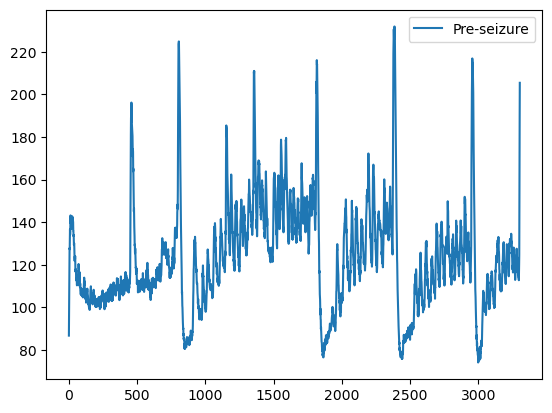

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-09_2photon_sess-01-6dpf_PTZ20_run-01_pre_regtrace.npy


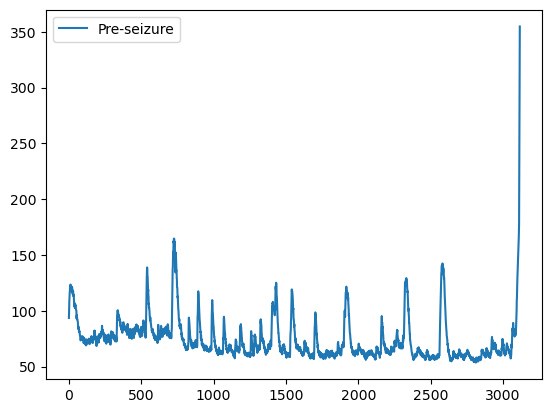

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run-01_pre_regtrace.npy


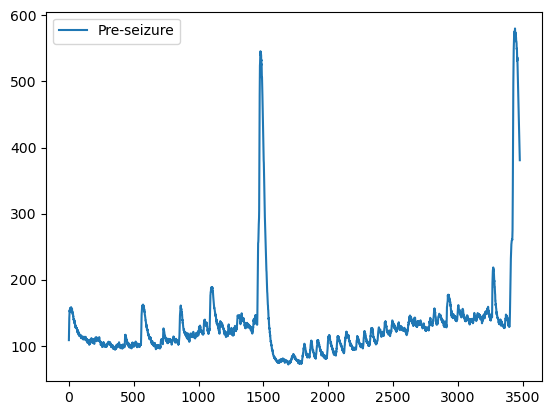

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run-01_pre_regtrace.npy


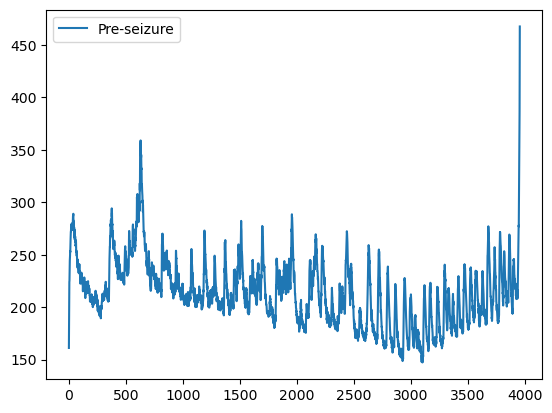

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_pre_regtrace.npy


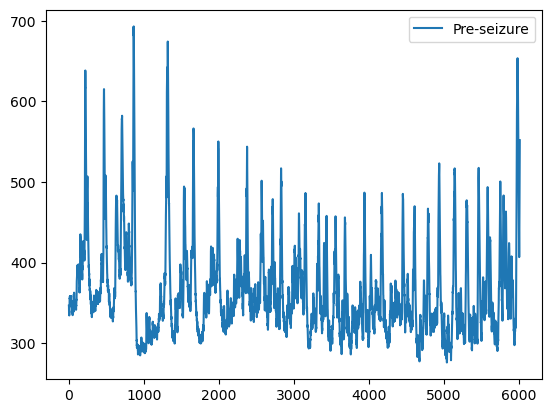

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_pre_regtrace.npy


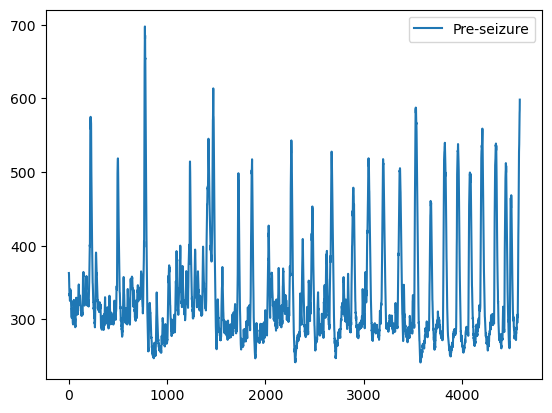

In [102]:
#sanity check
#preseizure
pre_li = np.sort(glob.glob(data + '/*PTZ20*pre*regtrace*'))

for i in pre_li:
    curr = np.load(i)  # shape: (n_neurons, n_timepoints)
    print(i)

    mean_activity = np.mean(curr, axis=0)
    baseline_mean = np.mean(mean_activity)
    baseline_std = np.std(mean_activity)

    # Plot
    plt.figure()
    plt.plot(mean_activity, label='Pre-seizure')
    plt.legend()
    plt.show()


/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


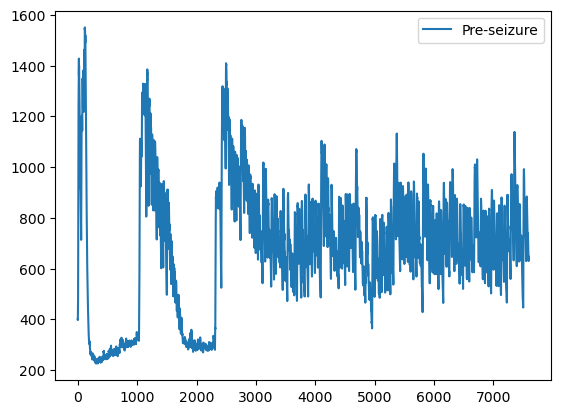

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


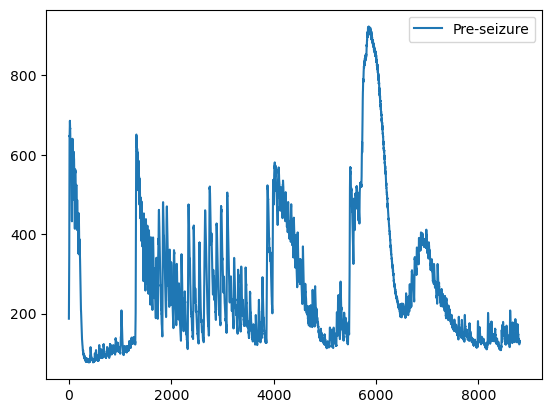

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


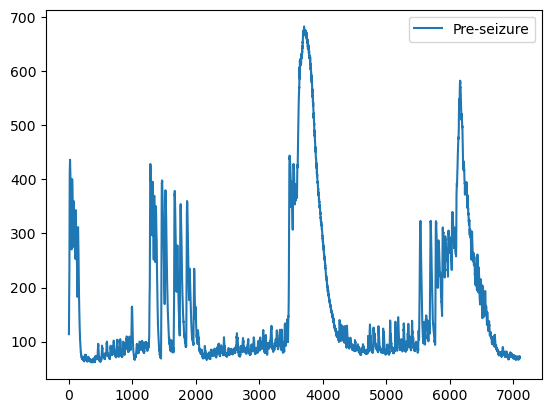

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


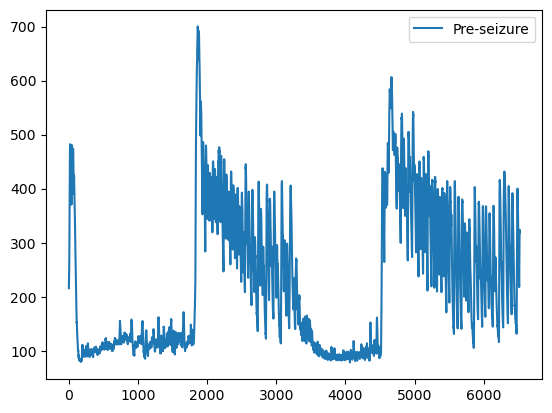

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


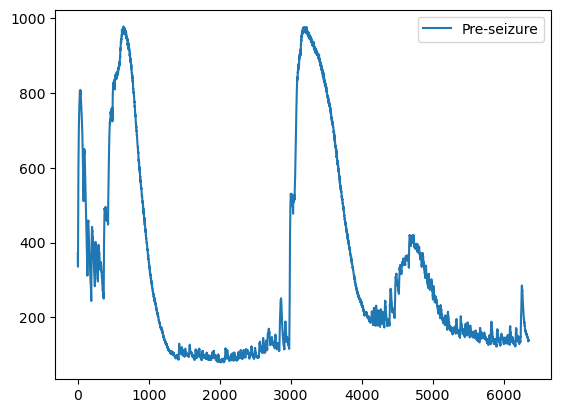

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


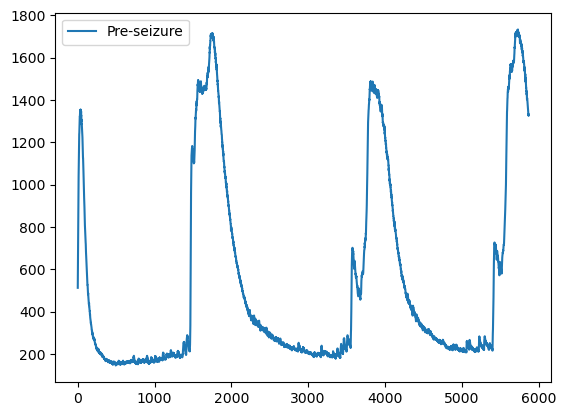

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_sz_regtrace.npy


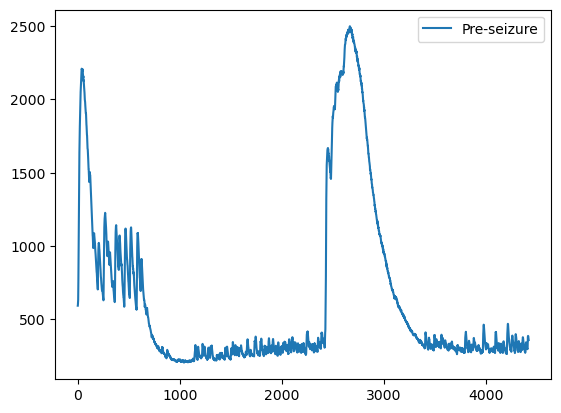

In [103]:
#sanity check
#seizure
sz_li = np.sort(glob.glob(data + '/*PTZ20*sz*regtrace*'))

for i in sz_li:
    curr = np.load(i)  # shape: (n_neurons, n_timepoints)
    print(i)

    mean_activity = np.mean(curr, axis=0)
    baseline_mean = np.mean(mean_activity)
    baseline_std = np.std(mean_activity)

    # Plot
    plt.figure()
    plt.plot(mean_activity, label='Pre-seizure')
    plt.legend()
    plt.show()


# Group seizure data for kEDM

In [142]:
data

'/snl/scratch25/dburrows/CCM'

In [143]:
#confirm data is ordered correctly

#NB - kEDM wants data structured as: time x cells
#CCM_seizure_sort function adds in a meantrace and saves traces as: cells x time in .npy dict, but time x cells in .h5 
import glob

co_l = sorted(glob.glob(data + '/*PTZ20*labcoord*'))[3:]
tr_l = sorted(glob.glob(data + '/*PTZ20*pre*regtrace*'))
dff_l = sorted(glob.glob(data + '/*PTZ20*pre*regdelta*npy'))


assert len(co_l) == len(tr_l) == len(dff_l)
for i in range(len(co_l)):
    assert tr_l[i][0:tr_l[i].find('run')+7] == co_l[i][0:co_l[i].find('run')+7] == dff_l[i][0:dff_l[i].find('run')+7]

AssertionError: 

In [201]:
tr_l = sorted(glob.glob(data + '/smoothed/sigma_4/*regtrace*'))
dff_l = sorted(glob.glob(data + '/smoothed/sigma_4/*regtrace*'))
co_l = [f'{data}/{os.path.basename(tr_l[i]).split("run")[0]}run-01_labcoord.npy' for i in range(len(tr_l))]

assert len(co_l) == len(tr_l) == len(dff_l)
for i in range(len(co_l)):
    assert os.path.basename(tr_l[i][0:tr_l[i].find('run')+7]) == os.path.basename(co_l[i][0:co_l[i].find('run')+7])

In [180]:
#check shape
                                                            
for i in range(len(co_l)):
    co = np.load(co_l[i])
    tr = np.load(tr_l[i])
    dff = np.load(dff_l[i])
    print(co.shape, tr.shape, dff.shape)


(11779, 5) (11779, 9828) (11779, 9828)
(11197, 5) (11197, 9828) (11197, 9828)
(7970, 5) (7970, 9828) (7970, 9828)
(7970, 5) (7970, 7595) (7970, 7595)
(7081, 5) (7081, 9828) (7081, 9828)
(7081, 5) (7081, 8809) (7081, 8809)
(6894, 5) (6894, 4914) (6894, 4914)
(8672, 5) (8672, 4914) (8672, 4914)
(7106, 5) (7106, 9828) (7106, 9828)
(9551, 5) (9551, 9828) (9551, 9828)


KeyboardInterrupt: 

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


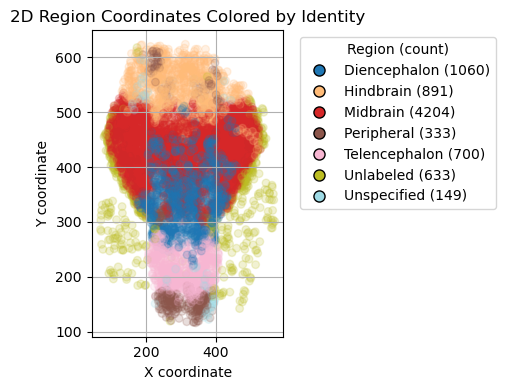

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


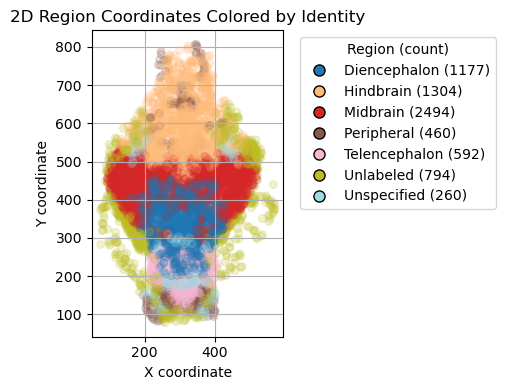

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


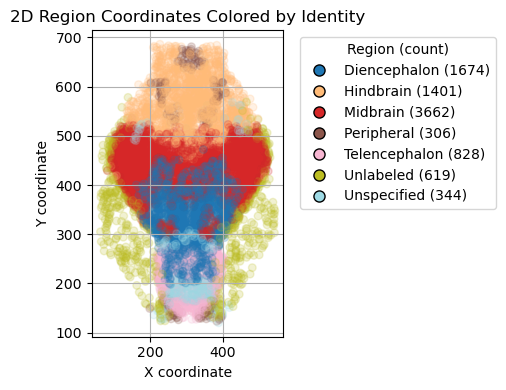

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


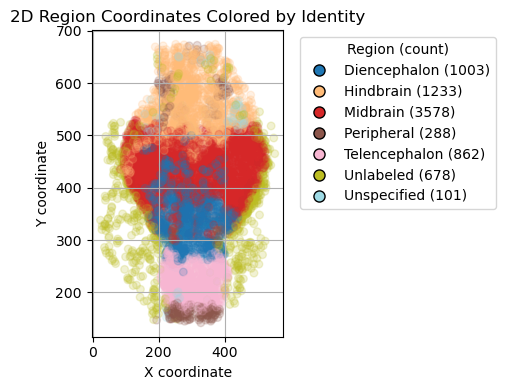

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


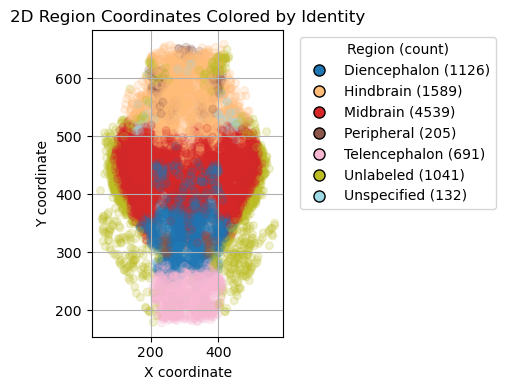

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


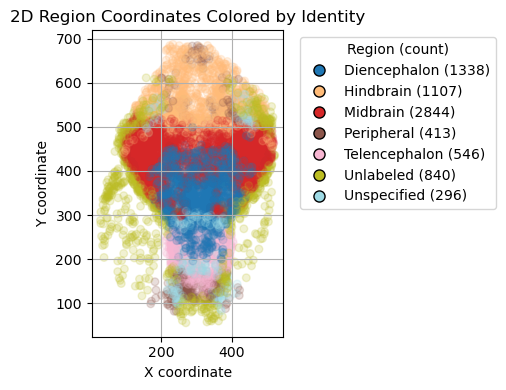

/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy


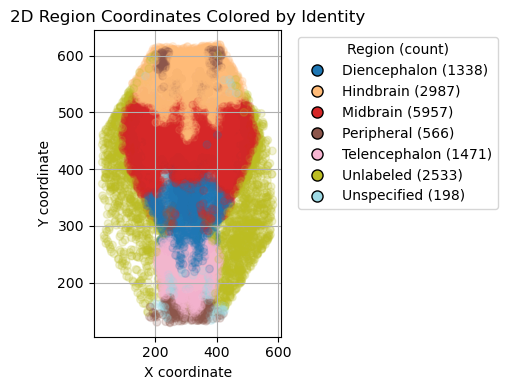

In [192]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Loop through each file in the list
for i in range(len(co_l)):
    print(co_l[i])
    co = np.load(co_l[i])

    # Convert coordinates to integers
    x = co[:, 0].astype(float).astype(int)
    y = co[:, 1].astype(float).astype(int)

    # Get region labels from the last column
    labels = co[:, -1]
    labels = np.where(labels == 'nan', 'Unlabeled', labels)

    # Count number of points per region
    region_counts = Counter(labels)

    # Unique labels and colors
    unique_labels = sorted(region_counts.keys())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    # Assign colors
    point_colors = [label_to_color[label] for label in labels]

    # Plot
    plt.figure(figsize=(5, 4))
    scatter = plt.scatter(x, y, c=point_colors, s=30, alpha=0.2)

    # Legend with counts
    handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   label=f"{label} ({region_counts[label]})",
                   markerfacecolor=color, markeredgecolor='k', markersize=8)
        for label, color in label_to_color.items()
    ]
    plt.legend(handles=handles, title="Region (count)", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title("2D Region Coordinates Colored by Identity")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [199]:
os.path.dirname(tr_l[i]) +'/'+ os.path.basename(tr_l[i]).split('regtrace')[0][:-1]

'/snl/scratch25/dburrows/CCM/smoothed/sigma_2/PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01'

In [203]:
%autoreload
# Split data into increasing time intervals for CCM convergence 
div_list = [2,4,8]
for i in range(len(co_l)):
    co = np.load(co_l[i])
    tr = np.load(tr_l[i])
    dff = np.load(dff_l[i])
    for d in div_list:
        sub_tr = tr[:,:(int(tr.shape[1]/d))]
        sub_dff = dff[:,:(int(dff.shape[1]/d))]
        name = os.path.dirname(tr_l[i]) +'/'+ os.path.basename(tr_l[i]).split('regtrace')[0][:-1] + '_interval-' + '1.' + str(d) 
        f_dict = cfn.CCM_seizure_sort(co, sub_tr, sub_dff, name)
        print('Done ' + co_l[i])

Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_labcoord.npy
Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-

Done /snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01_labcoord.npy


In [197]:
os.path.dirname(tr_l[i]) +'/'+ os.path.basename(tr_l[i]).split('regtrace')[0][:-1]

'/snl/scratch25/dburrows/CCM/smoothed/sigma_2/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_'

In [202]:
#Save dict containing all data and hdf5 files for CCM
                                                            
for i in range(len(co_l)):
    co = np.load(co_l[i])
    tr = np.load(tr_l[i])
    dff = np.load(dff_l[i])
    name = os.path.dirname(tr_l[i]) +'/'+ os.path.basename(tr_l[i]).split('regtrace')[0][:-1]
    f_dict = cfn.CCM_seizure_sort(co, tr, dff, name)
    
    print('Done ' + name)

Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_sz
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_sz
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_sz
Done /snl/scratch25/dburrows/CCM/smoothed/sigma_4/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-

# Process any trace data only for kEDM

In [23]:
#NB - kEDM wants data structured as: time x cells
#CCM_trace_save function renames and saves trace data as: time x cells, and 
# then saves the trace in the correct orientation in h5 format

tr_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM/kostas', '*dat*.npy*')
tr_l

['datNeuralSPIKFiltAndStim.npy']

In [24]:
np.load(tr_l[0]).shape

(11929, 6336)

In [8]:
%autoreload

In [25]:
#NB - must have datatype after 'run-XX_'
data = tr_l[0]
name = 'KOSTAS_220628-1312_2photon_sess-01-6dpf_run-01_trace'
data, name

('datNeuralSPIKFiltAndStim.npy',
 'KOSTAS_220628-1312_2photon_sess-01-6dpf_run-01_trace')

In [26]:
#Save 
cfn.CCM_trace_save(data, name)

# Estimate embedding dimension

In [13]:
#kedm-xmap estimation of E is poor - use pyEDM instead

ok = glob.glob('/snl/scratch25/dburrows/CCM/*PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_interval-1.2_trace_pre-CCM*')
ok

['/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_interval-1.2_trace_pre-CCM.h5',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_interval-1.2_trace_pre-CCM_E.npy']

In [12]:
np.load(ok[0]).shape, np.load(ok[2]).shape

((11039,), (11039,))

In [18]:
import h5py
import numpy as np

# Add it to the HDF5 input file
with h5py.File(ok[0], 'r') as f:
    print(list(f.keys()))
    d=f['data'][:]


['data']


In [20]:
d.shape

(4914, 11039)

In [ ]:
#batch run pyEDM on all -> compute for mean too! - aori
#delete all xmap
#run kedm on all - check you have the right pairing for each file

# Check for stationarity

In [88]:
prac = glob.glob(f'{data}/*stat*')
curr = pd.read_csv(prac[1])
curr['cond'] = [i.split('_')[3] for i in pd.read_csv(prac[0])['File']]

In [89]:
curr

,File,PC,E,TargetChunk,rho,cond
0,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...,1,2,self,0.996887,BLN
1,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...,1,2,2nd,0.643729,BLN
2,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...,1,2,3rd,0.740607,BLN
3,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...,2,5,self,0.977176,BLN
4,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...,2,5,2nd,0.976182,BLN
...,...,...,...,...,...,...
1135,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...,9,4,2nd,0.982097,PTZ05
1136,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...,9,4,3rd,0.978250,PTZ05
1137,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...,10,3,self,0.989497,PTZ05
1138,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...,10,3,2nd,0.984500,PTZ05


In [14]:
#plot by condition, PC, self, 2nd, 3rd

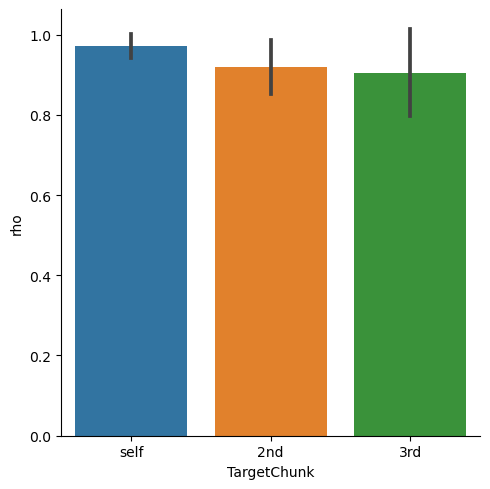

In [95]:
import seaborn as sns
i=5
sns.catplot(data=curr[curr['PC']==i], kind='bar', x = 'TargetChunk', y = 'rho', errorbar='sd')

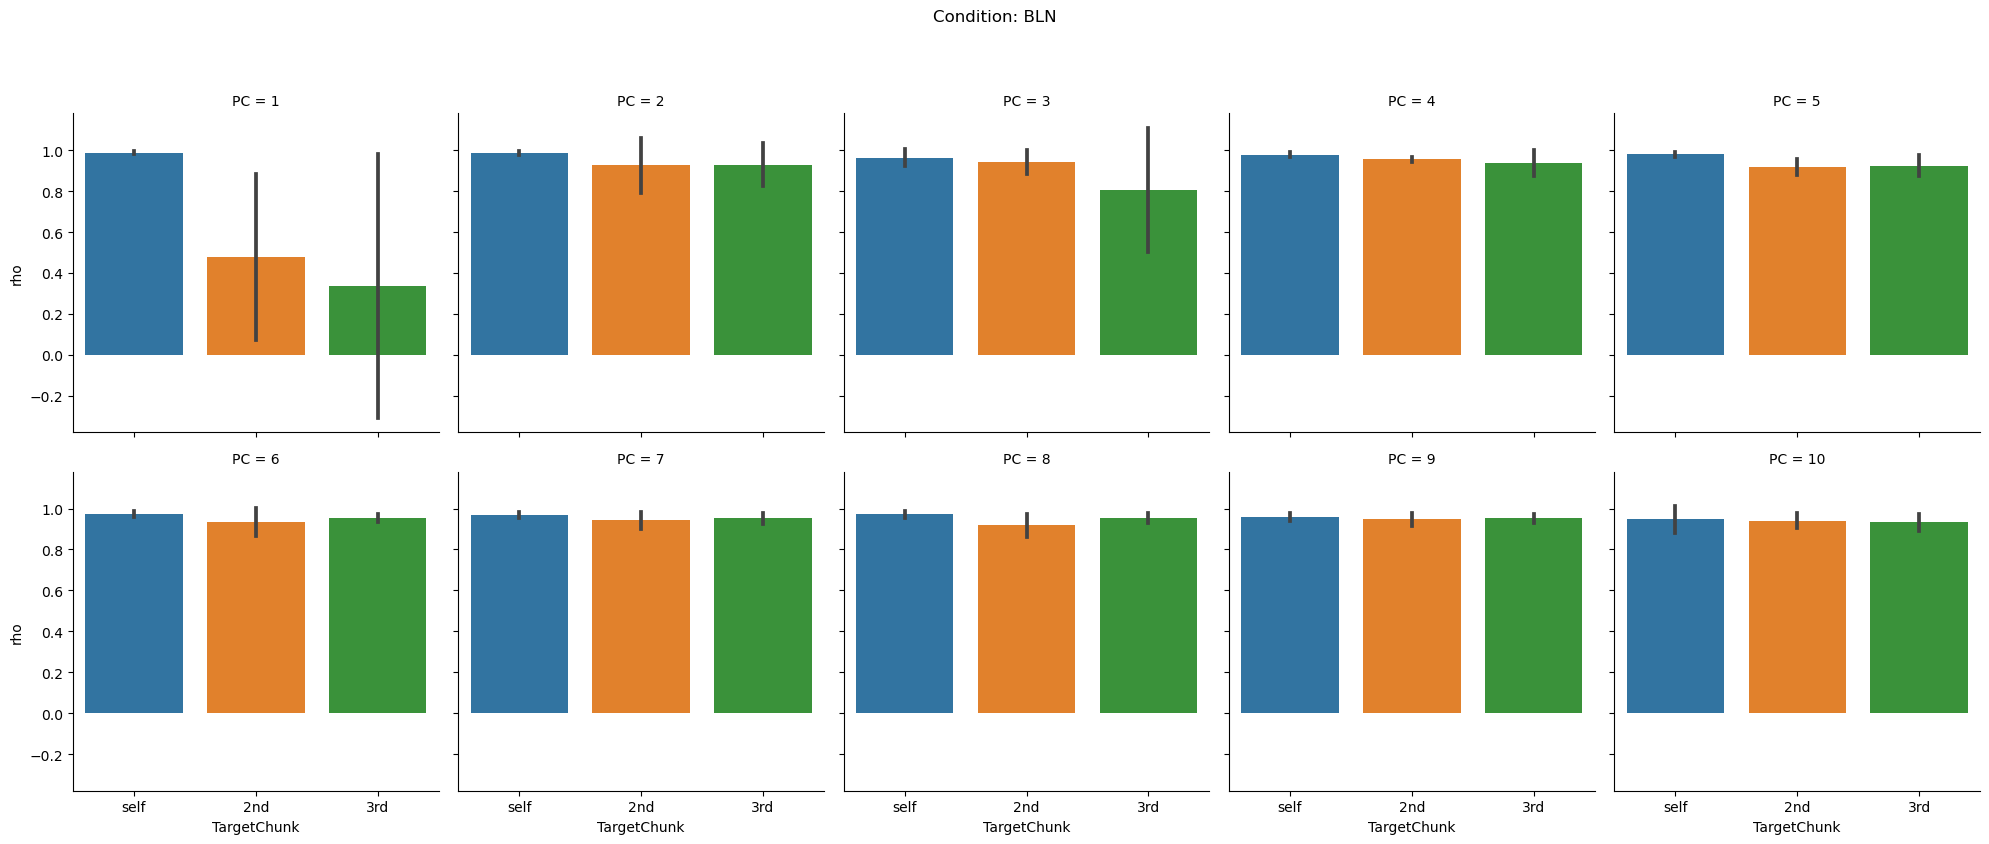

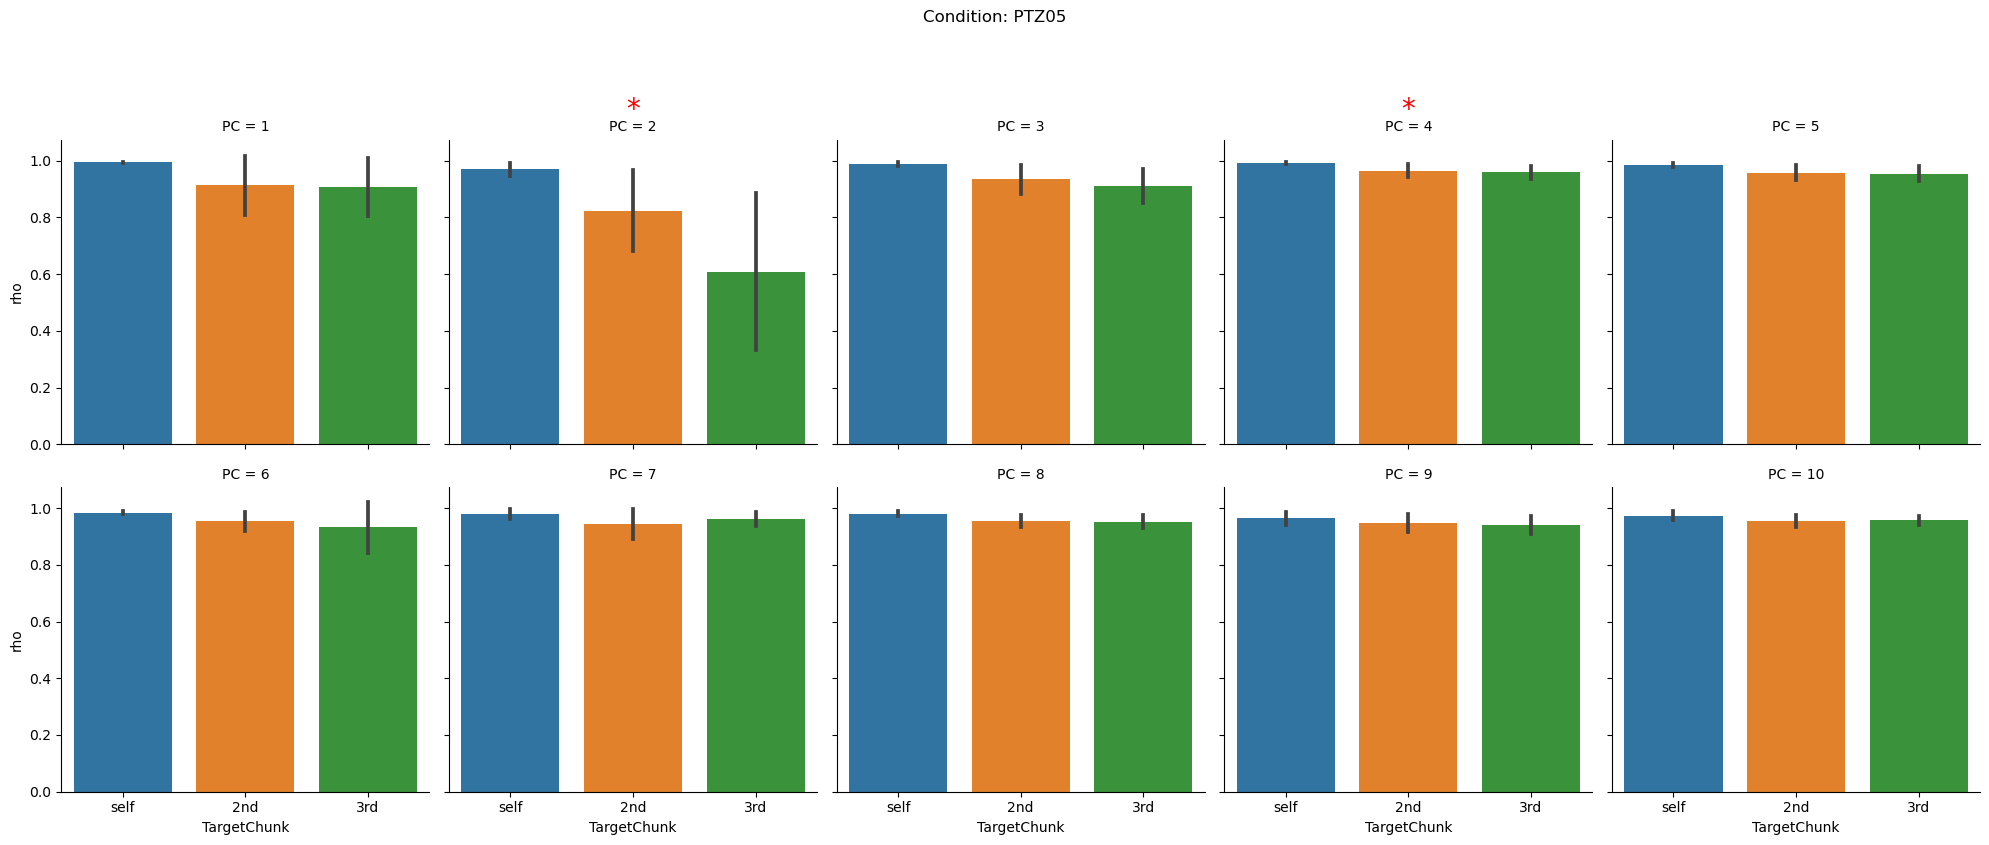

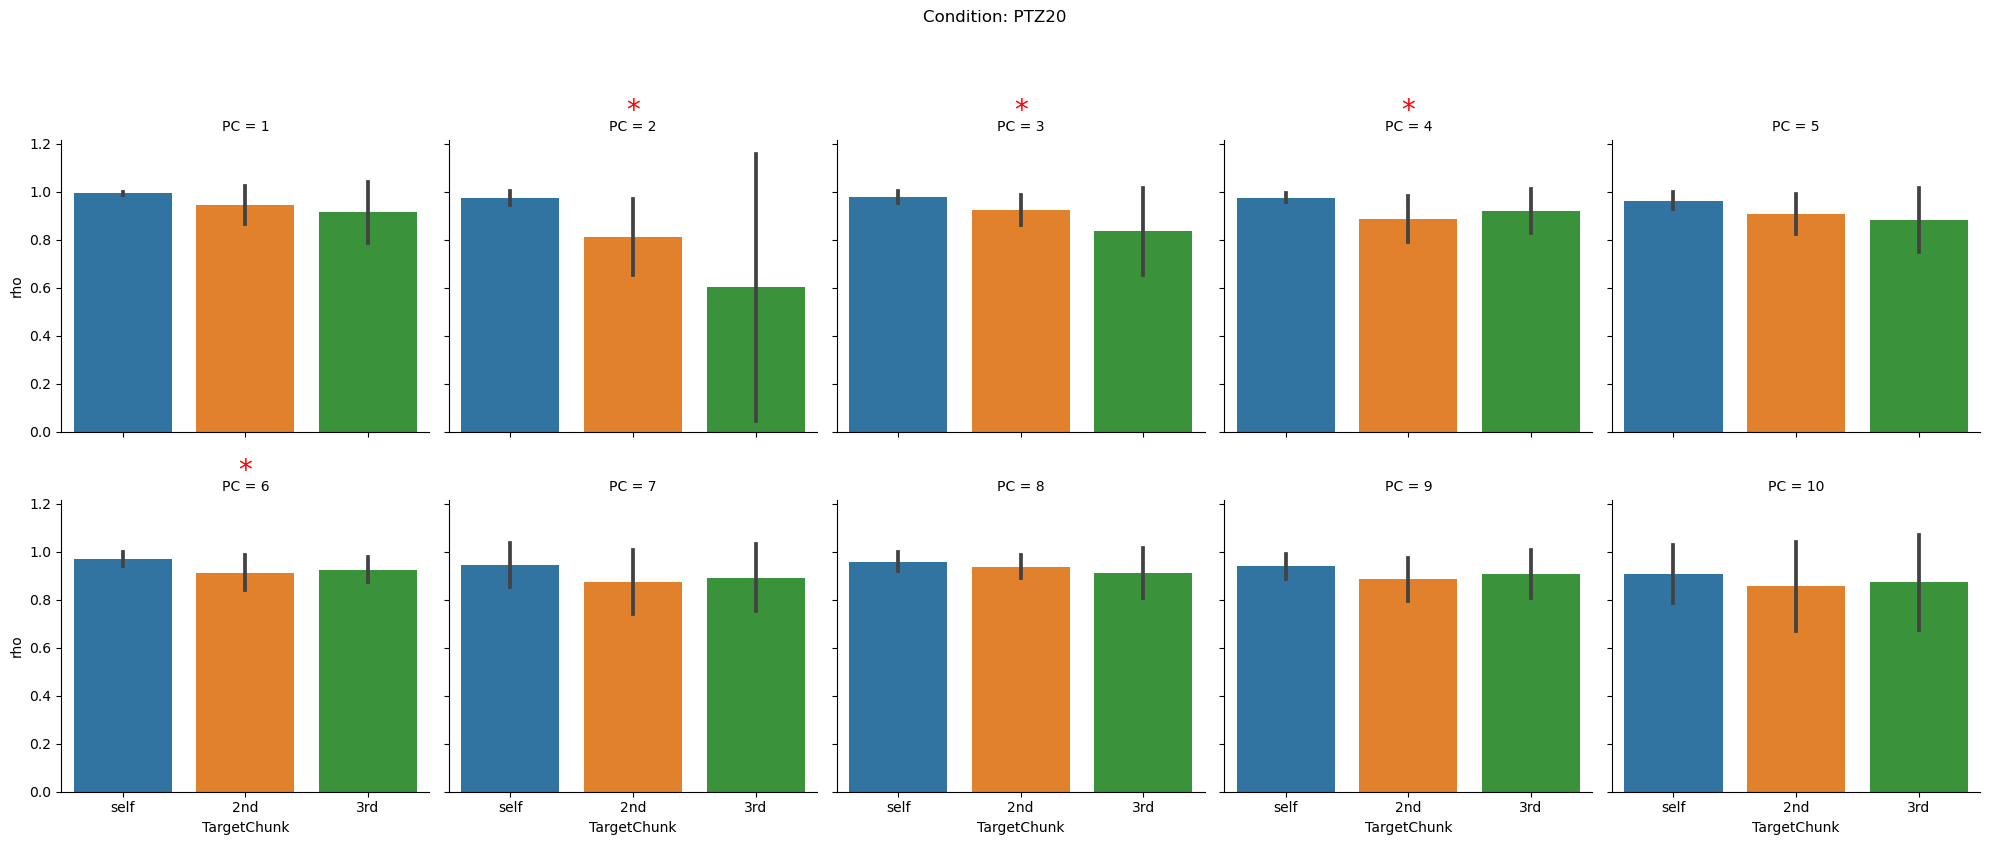

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import numpy as np

conditions = ['BLN', 'PTZ05', 'PTZ20']
pcs = range(1, 11)

for cond in conditions:
    subset = curr[(curr['cond'] == cond) & (curr['PC'].between(1, 10))]

    # Store significance for each PC
    significance = {}
    for pc in pcs:
        sub_pc = subset[subset['PC'] == pc]
        groups = [group['rho'].values for name, group in sub_pc.groupby('TargetChunk')]

        # Check if we have enough groups with values to do ANOVA
        if all(len(g) > 1 for g in groups) and len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            significance[pc] = p_val < (0.05/10)  # mark if significant
        else:
            significance[pc] = False

    # Plotting
    g = sns.catplot(
        data=subset,
        kind='bar',
        x='TargetChunk',
        y='rho',
        col='PC',
        col_wrap=5,
        errorbar='sd',
        height=4,
        aspect=1
    )

    g.fig.suptitle(f"Condition: {cond}", y=1.05)

    # Add asterisks for significant plots
    for ax in g.axes.flat:
        title = ax.get_title()
        if "PC = " in title:
            pc_val = int(title.split('=')[1].strip())
            if significance.get(pc_val, False):
                # Add asterisk annotation
                ax.text(
                    0.5, 1.05, '*', 
                    transform=ax.transAxes, 
                    ha='center', 
                    va='bottom', 
                    fontsize=20, 
                    color='red'
                )

    plt.tight_layout()
    plt.show()

In [96]:
def pc1_calc(li):
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    #plot PC1 across conditions
    df = pd.DataFrame()
    time, scores, names = [],[],[]
    for x,i in enumerate(li):
        d = np.load(i)

        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(d.T)
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(data_scaled)
        time.extend(np.arange(0,len(pcs)))
        scores.extend(pcs[:,1])
        names.extend(np.repeat(x,len(pcs)))
    scores = np.asarray(scores)#[:,0]
    df['scores']=scores
    df['time']=time
    df['name'] = names
    return(df)


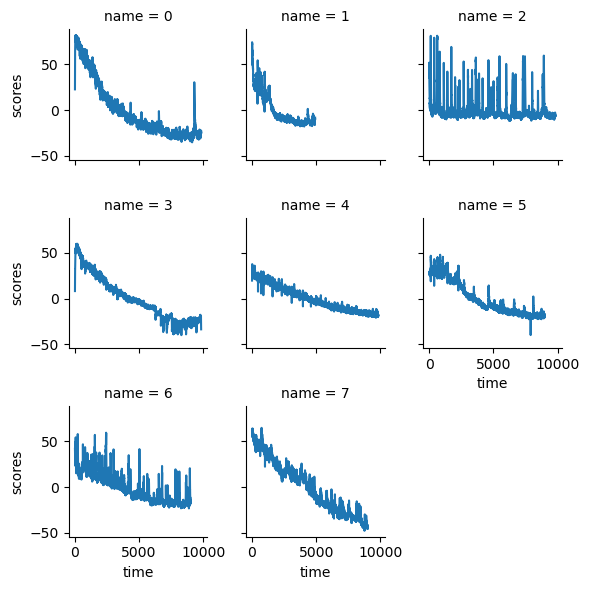

In [63]:
#BLN
df = pc1_calc(glob.glob(f'{data}/*BLN*regtrace*'))
sns.relplot(data=df, x = 'time', y = 'scores', col='name', col_wrap=3, kind='line', height=2)
plt.show()

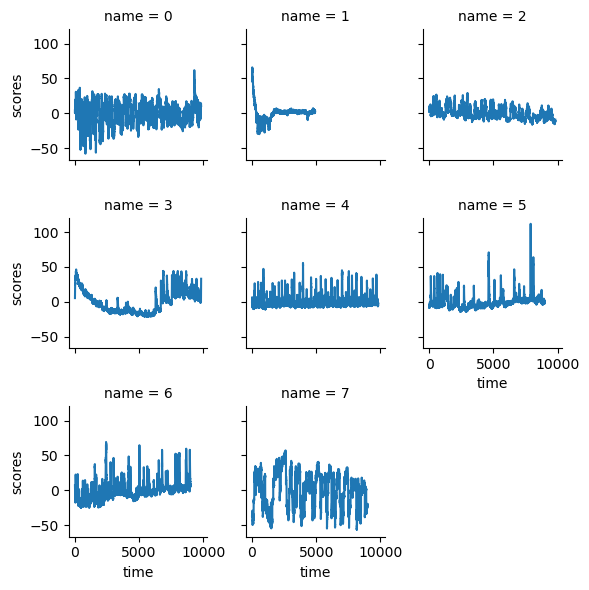

In [82]:
#BLN
df = pc1_calc(glob.glob(f'{data}/*BLN*regtrace*'))
sns.relplot(data=df, x = 'time', y = 'scores', col='name', col_wrap=3, kind='line', height=2)
plt.show()

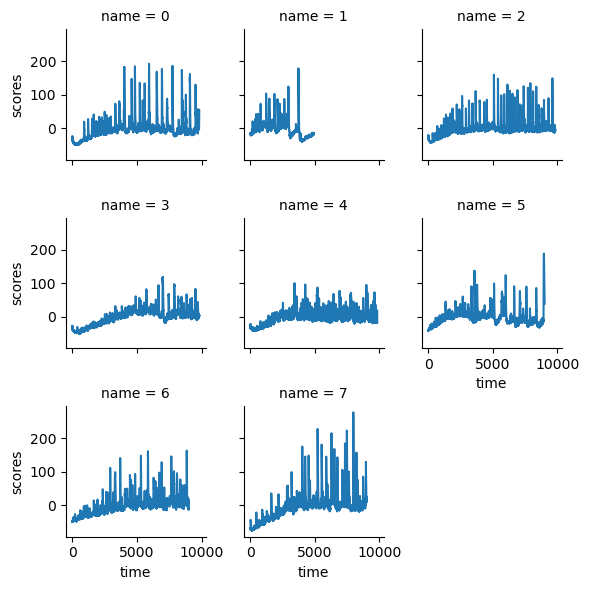

In [64]:
#PTZ05
df = pc1_calc(glob.glob(f'{data}/*PTZ05*regtrace*'))
sns.relplot(data=df, x = 'time', y = 'scores', col='name', col_wrap=3, kind='line', height=2)
plt.show()

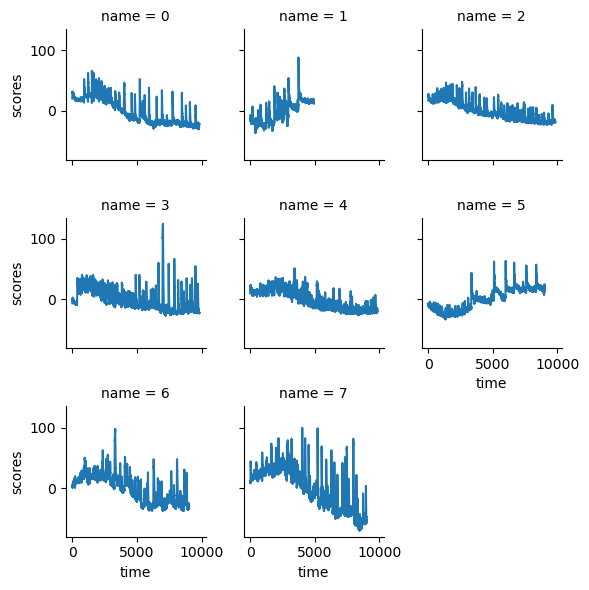

In [83]:
#PTZ05
df = pc1_calc(glob.glob(f'{data}/*PTZ05*regtrace*'))
sns.relplot(data=df, x = 'time', y = 'scores', col='name', col_wrap=3, kind='line', height=2)
plt.show()

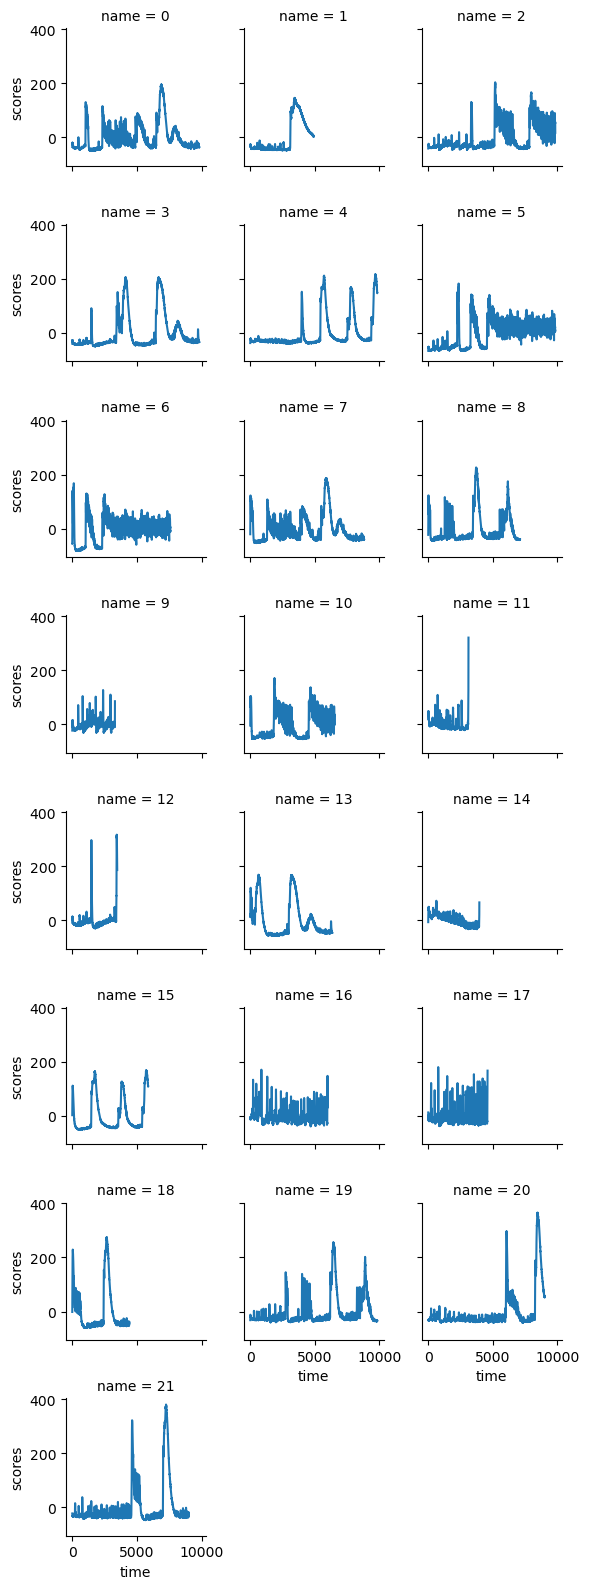

In [65]:
#PTZ20
df = pc1_calc(glob.glob(f'{data}/*PTZ20*regtrace*'))
sns.relplot(data=df, x = 'time', y = 'scores', col='name', col_wrap=3, kind='line', height=2)
plt.show()

# Smoothe data

In [113]:
#test out smoothing data for improved convergence
trace_l = glob.glob(f'{data}/*regtrace*npy')
trace_l

['/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-09_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_regtrace.npy',
 '/snl/scratch25/dburrows/CCM/PTZ-WILDTYPE-03_2photon_

In [109]:
prac = np.load(trace_l[1])
out = smooth_neural_activity(prac, sigma=2)

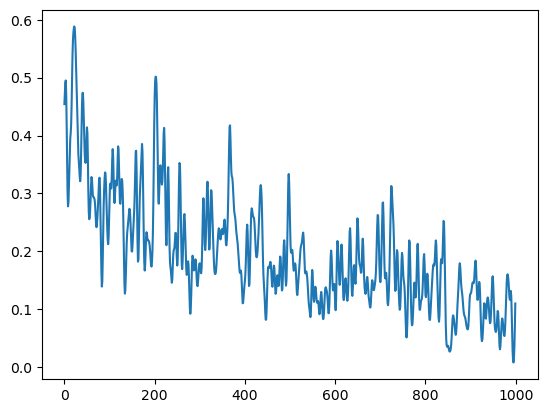

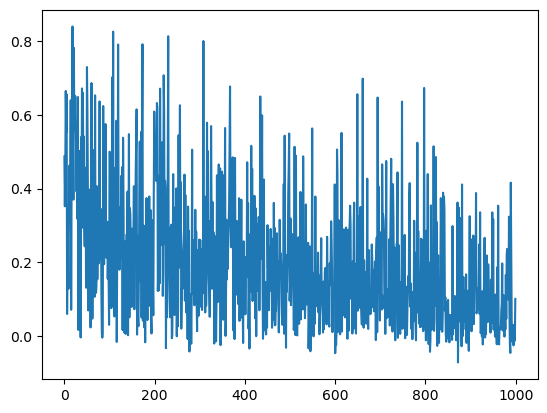

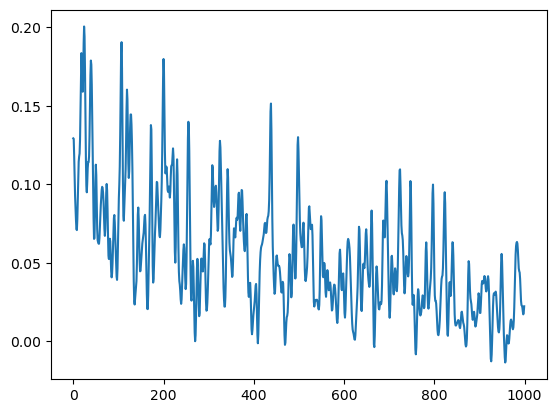

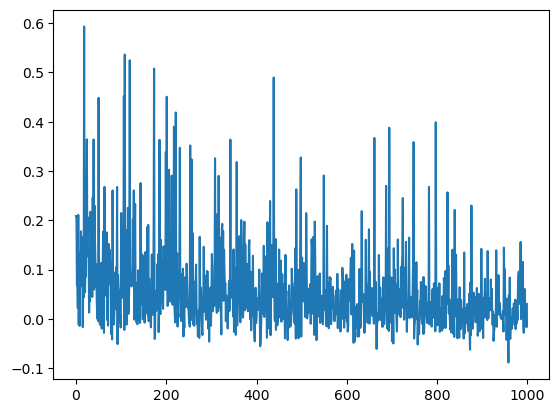

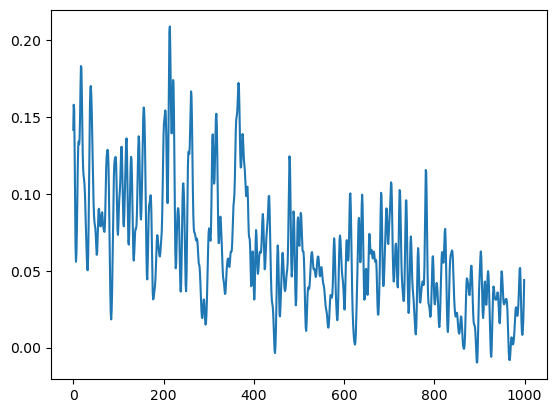

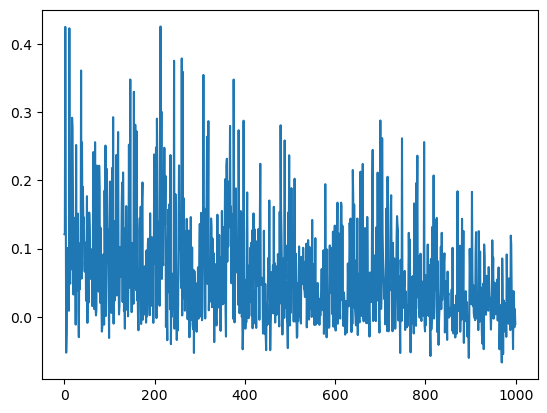

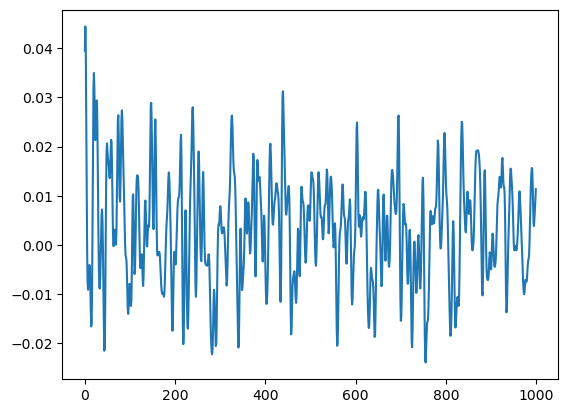

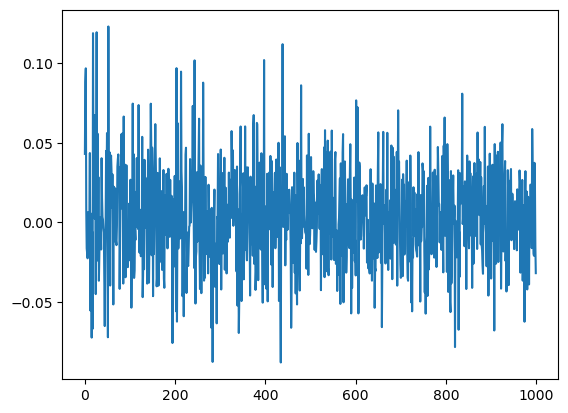

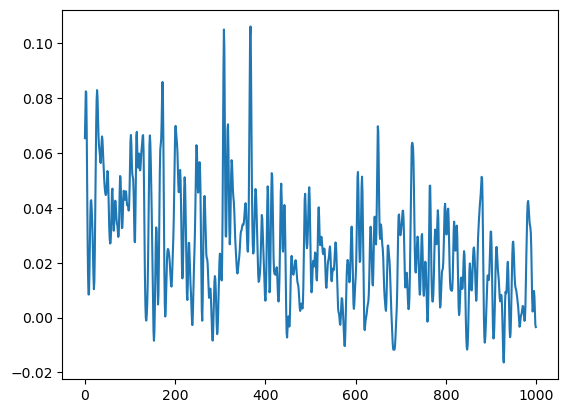

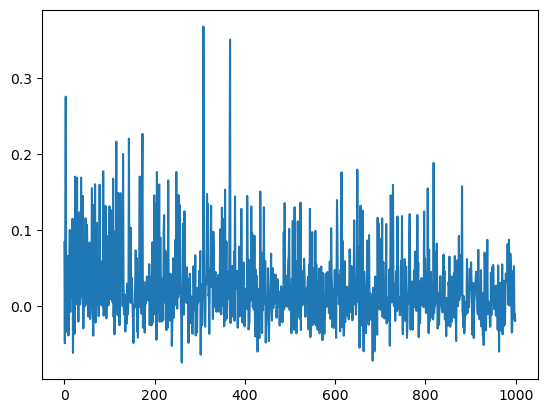

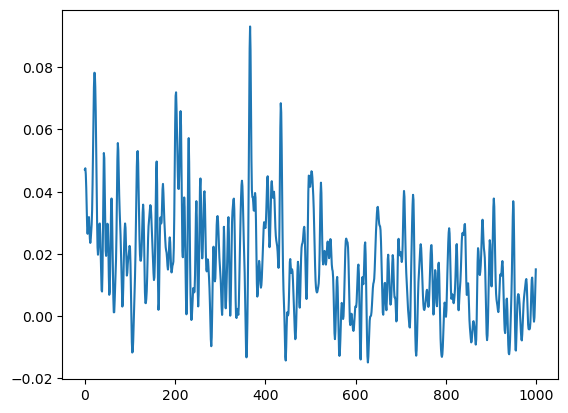

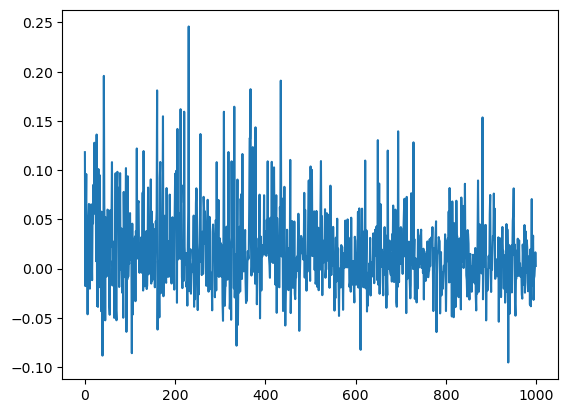

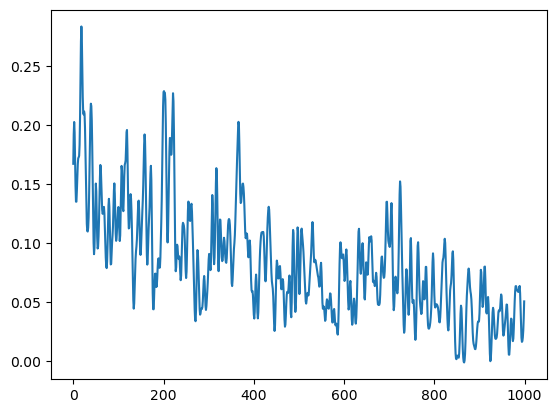

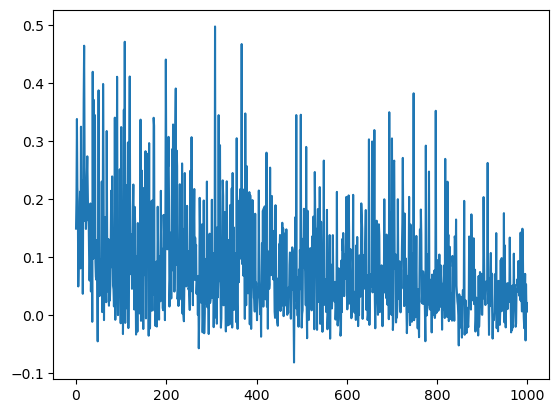

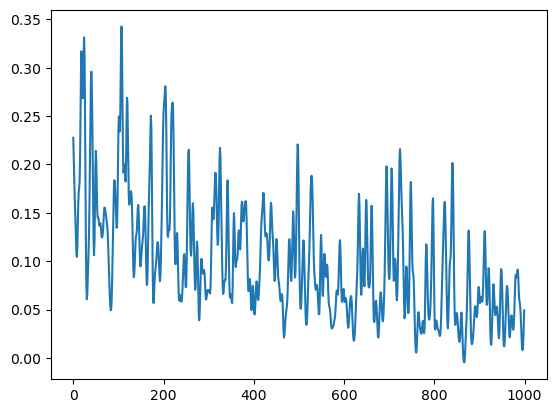

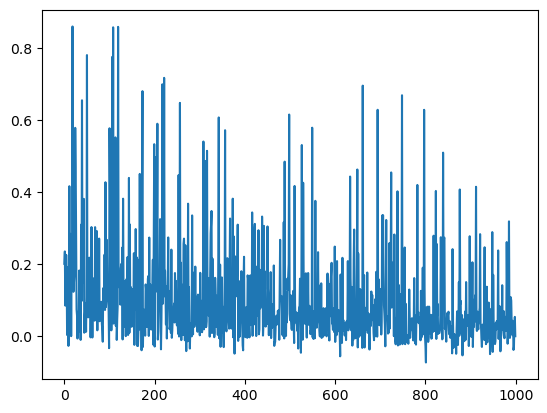

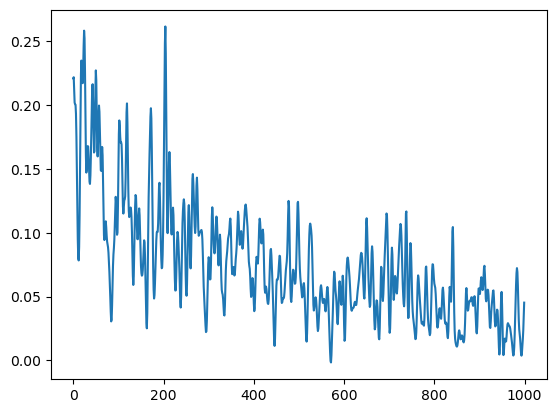

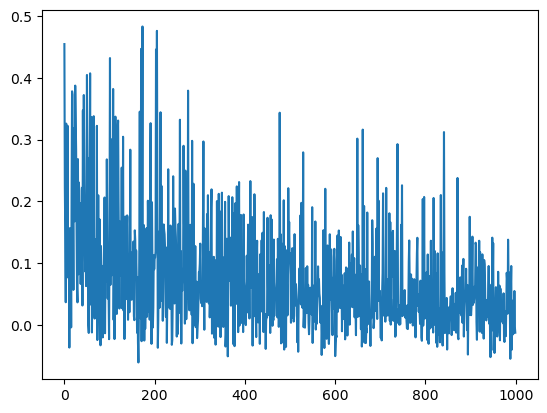

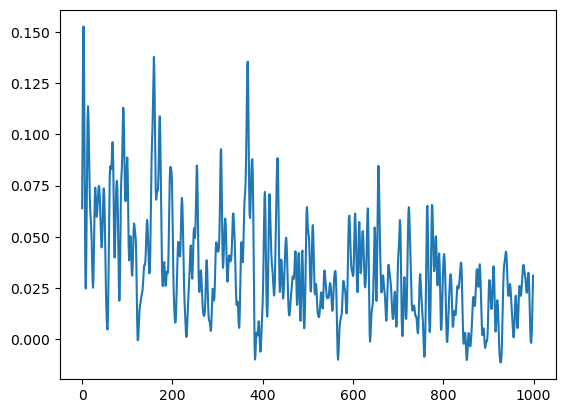

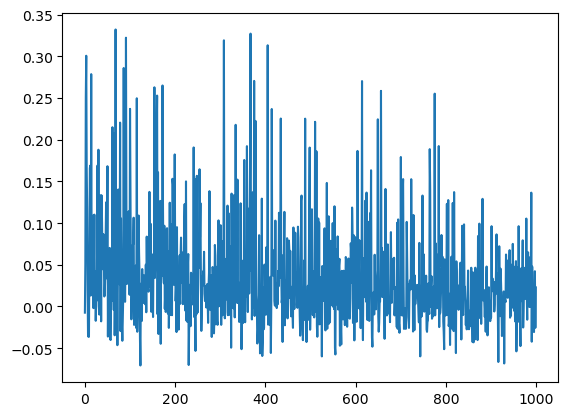

In [110]:
for i in range(10):
    plt.plot(out[i][2000:3000])
    plt.show()
    plt.plot(prac[i][2000:3000])
    plt.show()

In [141]:
#write function to smoothe all data
#==================================

from tqdm import tqdm

out_data = f'{data}/smoothed/'
for d in tqdm(trace_l, desc='Files'): 
    for sig in [2,4]:
        curr = np.load(d)
        smoothed = gaussian_filter1d(curr, sigma=sig, axis=1, mode='reflect')

        basename = os.path.basename(d).replace('.npy', '_smoothed.npy')
        np.save(f'{out_data}/sigma_{sig}/{basename}', smoothed)

        

Fi


In [ ]:
#